In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ggpubr))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(tidyr))

In [2]:
io = list()
io$main = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Shvartsman'

In [3]:
### Load data
metaE9.5 = fread(file.path(io$main, 'original/Metadata_E9_5.txt')) %>% .[,`:=`(cell=paste0('E9.5_', Cell_ID), stage='E9.5')]
metaE11.5 = fread(file.path(io$main, 'original/Metadata_E11_5.txt')) %>% .[,`:=`(cell=paste0('E11.5_', Cell_ID), stage='E11.5')]

countsE9.5 = fread(file.path(io$main, 'original/E9_5_rawcounts_matrix.tsv')) %>% 
        tibble::column_to_rownames('V1') %>% 
        as.matrix() %>% 
        as("sparseMatrix")
colnames(countsE9.5) = metaE9.5$cell

countsE11.5 = fread(file.path(io$main, 'original/E11_5_rawcounts_matrix.tsv')) %>% 
        tibble::column_to_rownames('V1') %>% 
        as.matrix() %>% 
        as("sparseMatrix")
colnames(countsE11.5) = metaE11.5$cell

Warning message in fread(file.path(io$main, "original/E9_5_rawcounts_matrix.tsv")):
“Detected 1378 column names but the data has 1379 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread(file.path(io$main, "original/E11_5_rawcounts_matrix.tsv")):
“Detected 1576 column names but the data has 1577 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [4]:
dim(countsE9.5)
dim(countsE11.5)

[1] 20575  1378

[1] 20823  1576

In [5]:
genes = intersect(rownames(countsE9.5), rownames(countsE11.5))
length(genes)

[1] 18323

In [6]:
countsE9.5 = countsE9.5[genes,]
countsE11.5 = countsE11.5[genes,]

In [7]:
meta = rbind(metaE9.5, metaE11.5)
counts = cbind(countsE9.5, countsE11.5)

In [8]:
sce = SingleCellExperiment(list(counts=counts))
colData(sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [9]:
# Remove lowly expressed genes
sce = sce[rowSums(counts(sce))>10]

In [10]:
# Add QC metrics
colData(sce) = cbind(colData(sce), perCellQCMetrics(sce))
# For some reason I can't find mitochondrial genes in the data

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


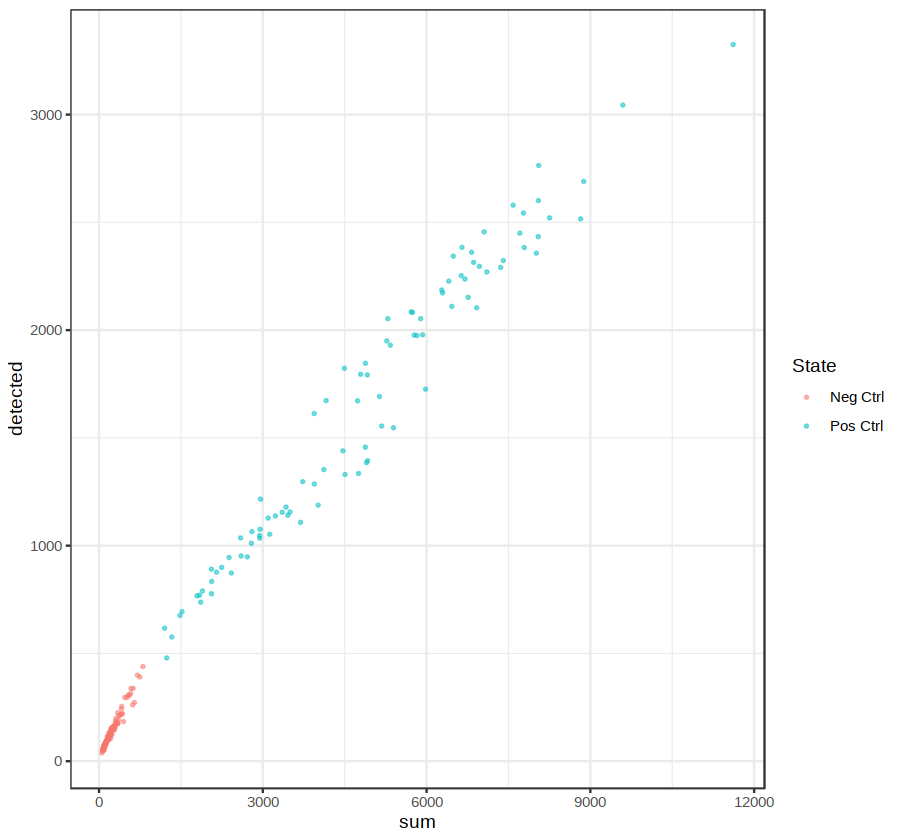

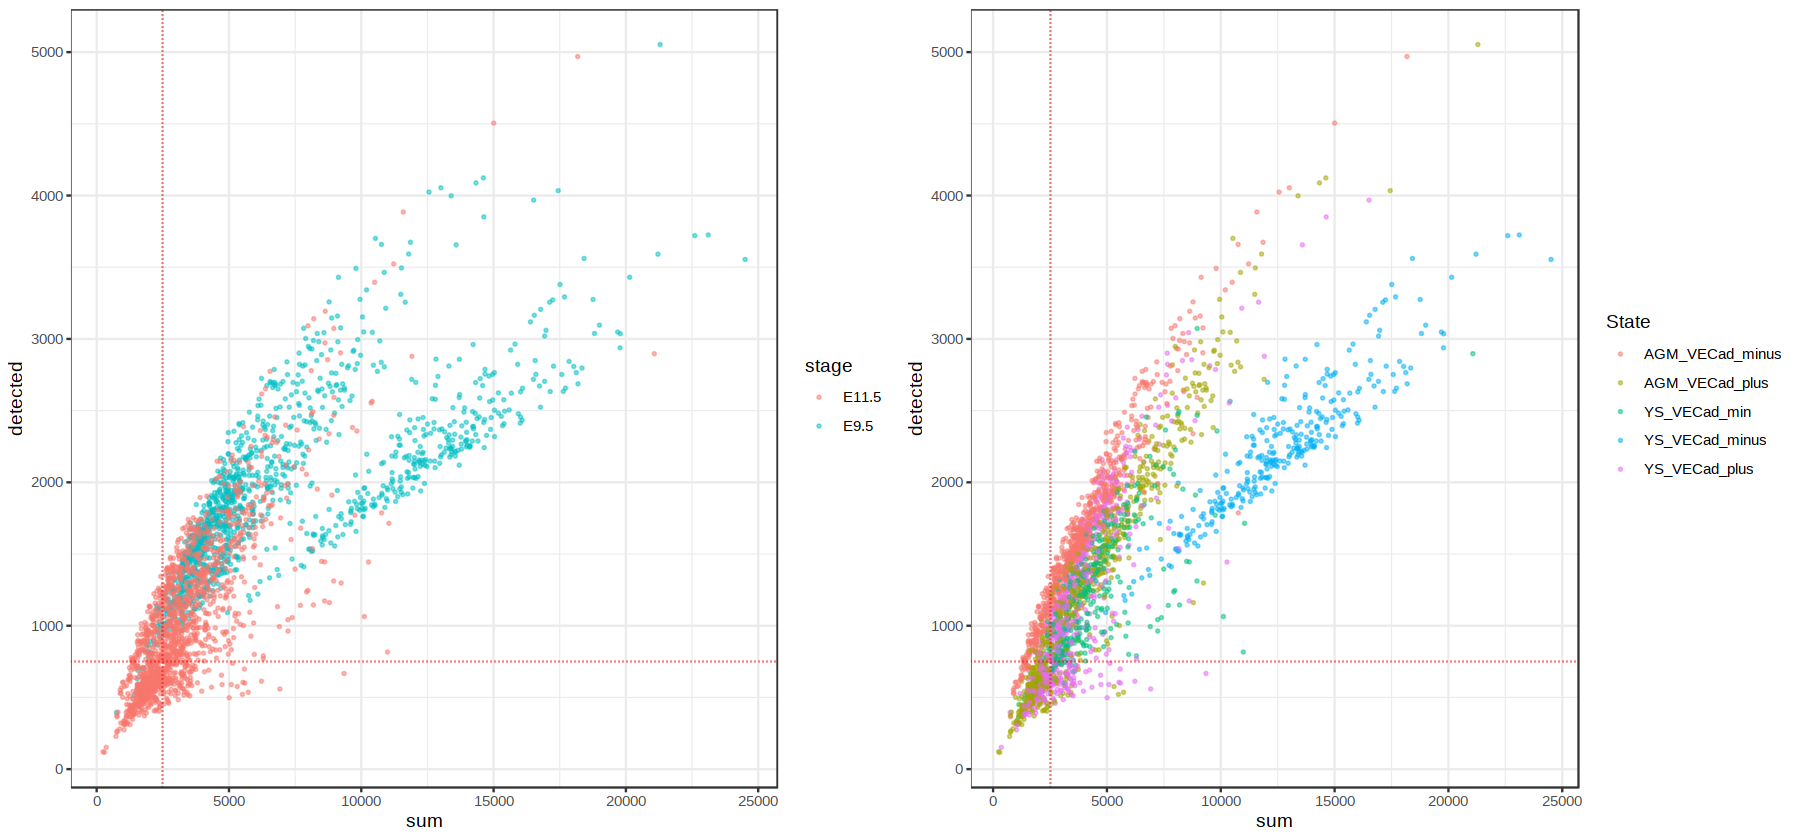

In [11]:
# Inspect QC
meta = as.data.table(colData(sce), keep.rownames=T)

# QC of positive and negative control
options(repr.plot.width=7.5)
ggplot(meta[State%in%c('Pos Ctrl', 'Neg Ctrl')], aes(sum, detected, col=State)) +
        geom_point(size=0.5, alpha=0.5) +
        theme_bw()

# And other cells
options(repr.plot.width=15)
ggarrange(
    ggplot(meta[!State%in%c('Pos Ctrl', 'Neg Ctrl')], aes(sum, detected, col=stage)) +
        geom_point(size=0.5, alpha=0.5) +
        geom_vline(xintercept = 2500, linetype='dotted', color='red') + 
        geom_hline(yintercept = 750, linetype='dotted', color='red') + 
        theme_bw(),
    ggplot(meta[!State%in%c('Pos Ctrl', 'Neg Ctrl')], aes(sum, detected, col=State)) +
        geom_point(size=0.5, alpha=0.5) +
        geom_vline(xintercept = 2500, linetype='dotted', color='red') + 
        geom_hline(yintercept = 750, linetype='dotted', color='red') + 
        theme_bw()
)

meta = meta[sum>=2500 & detected>=750 & !State%in%c('Pos Ctrl', 'Neg Ctrl')]


# QC looks a bit strange tbh, quite low reads and genes detected

In [12]:
# Subset to cells that passQC 
sce = sce[,meta$rn]

In [13]:
# Log normalisation
sce = logNormCounts(sce)

# Endothelial cells only

### E9.5

In [17]:
unique(meta$State)

[1] "YS_VECad_plus"   "AGM_VECad_plus"  "YS_VECad_minus"  "AGM_VECad_minus"
[5] "YS_VECad_min"

In [68]:
sce_endo = sce[,meta[State %in% c('YS_VECad_plus', 'AGM_VECad_plus') & stage=='E9.5', rn]]

In [94]:
# Remove Heamoglobin genes as they show up too high, likely as ambient RNA
excl = rownames(sce_endo)[c(grep('^Hbb', rownames(sce_endo)), grep('^Hba', rownames(sce_endo)))]

In [97]:
sce_endo = sce_endo[!rownames(sce_endo) %in% excl,]

In [99]:
# Determine HVGs
decomp = modelGeneVar(sce_endo)
decomp = decomp[decomp$mean > 0.01,]
hvgs = decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

# Subset SingleCellExperiment
sce_filt = sce_endo[hvgs,]

In [100]:
# Dimensionality reduction
sce_filt <- runPCA(sce_filt, ncomponents = 15, ntop=2500)

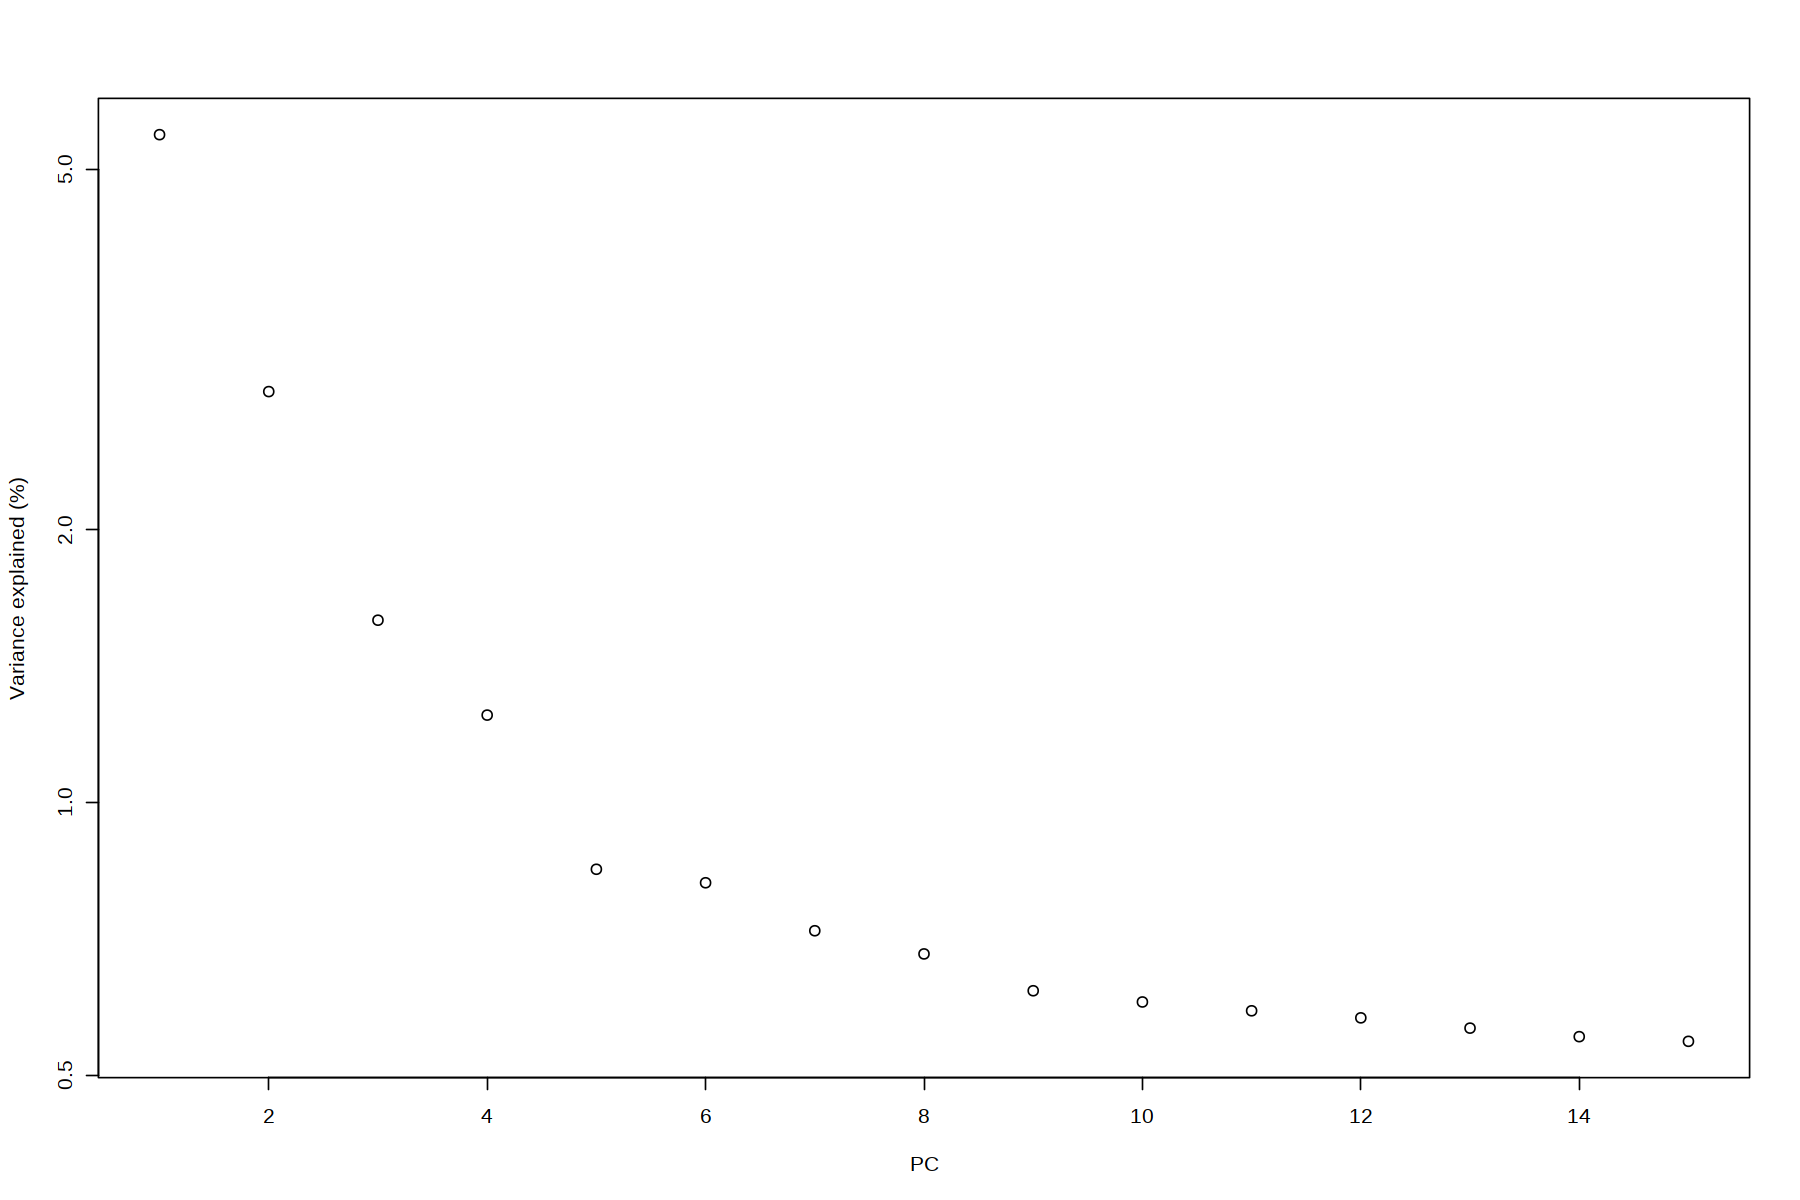

In [101]:
percent.var <- attr(reducedDim(sce_filt), "percentVar")
plot(percent.var, log="y", xlab="PC", ylab="Variance explained (%)")

In [102]:
# Let's use 10 PCs
sce_filt <- runPCA(sce_filt, ncomponents = 10, ntop=2500)

In [103]:
# Cluster
library(bluster)
nn.clusters <- clusterCells(sce_filt, use.dimred="PCA", BLUSPARAM=NNGraphParam(k=20))
colLabels(sce_filt) <- nn.clusters

In [104]:
# UMAP
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 0.2)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

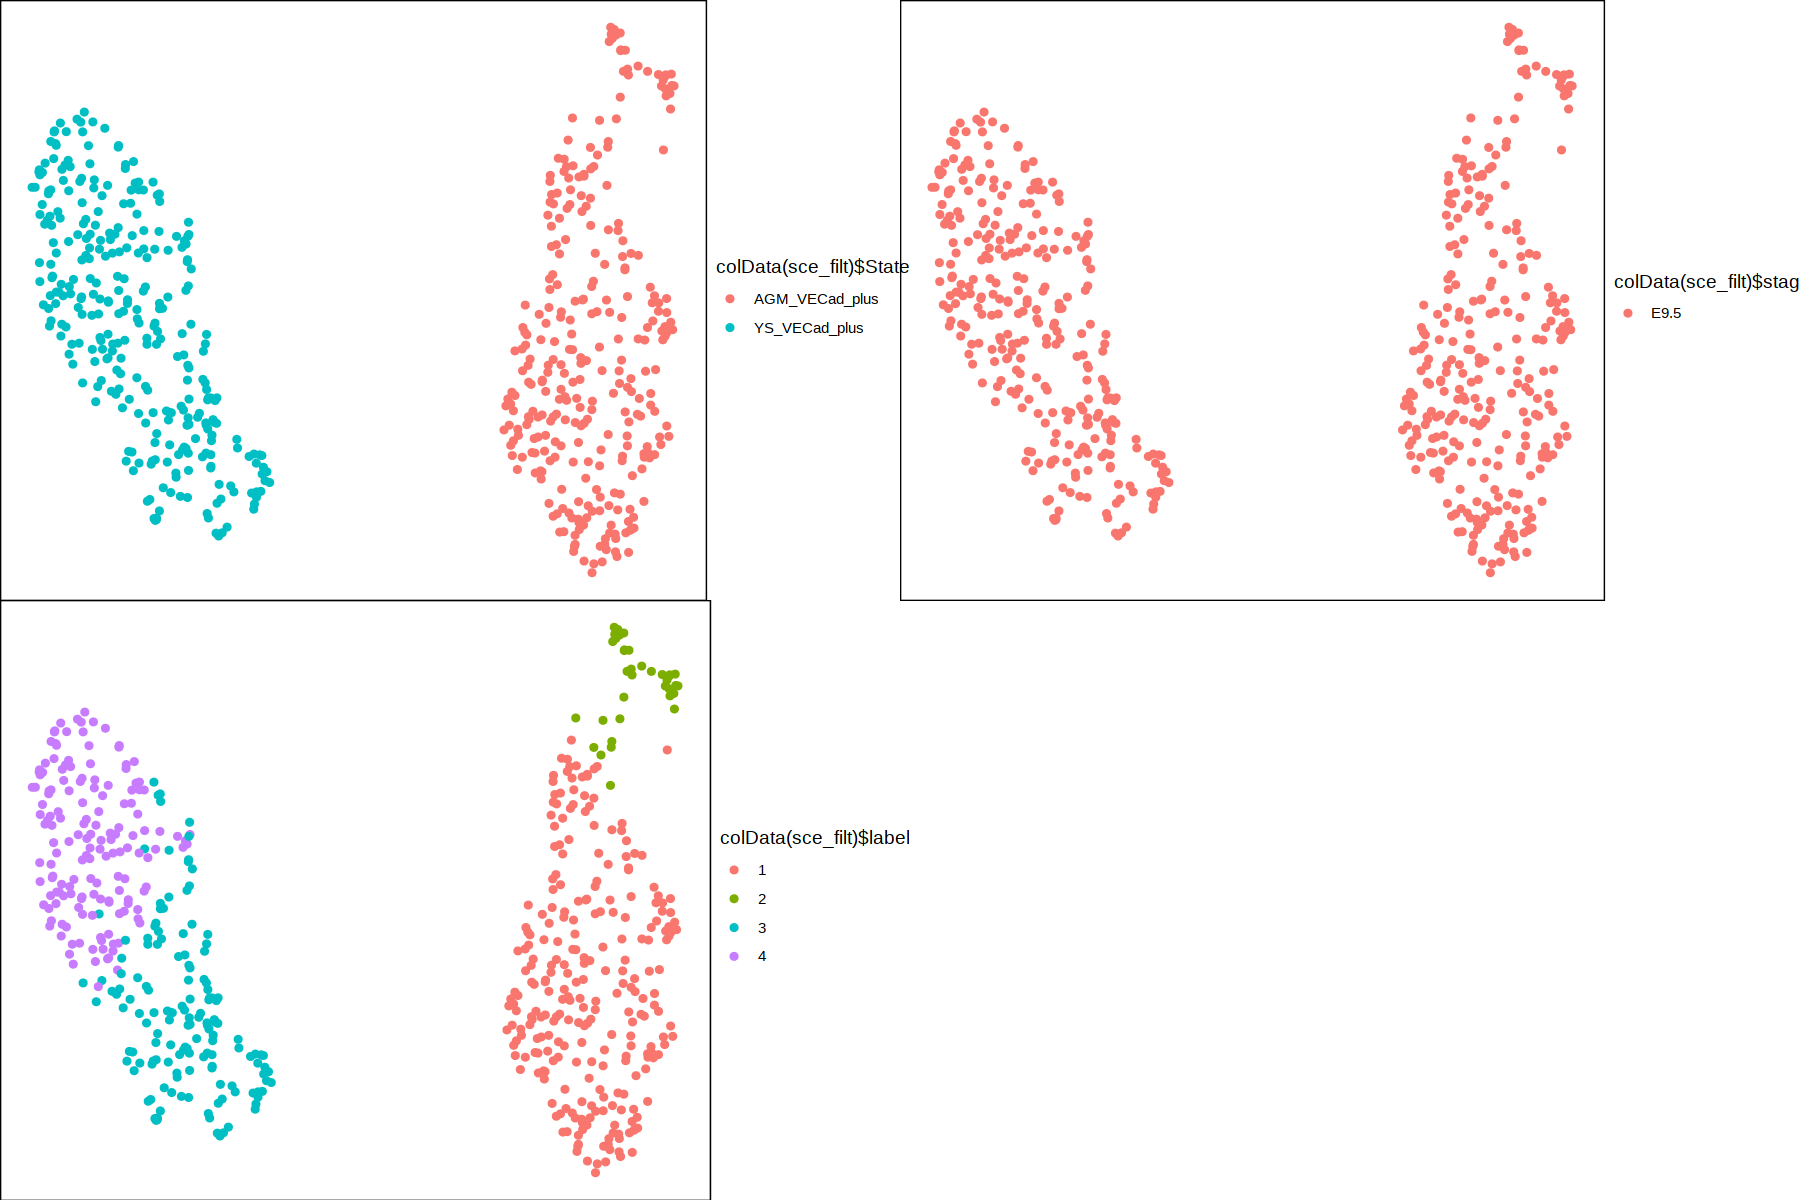

In [105]:
options(repr.plot.width=15,repr.plot.height=10)
ggarrange(
    ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$State)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)),
    ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$stage)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)),
     ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$label)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)))

In [106]:
marker <- scoreMarkers(sce_endo, colData(sce_endo)$State)
colData(sce_endo)$label = colData(sce_filt)$label

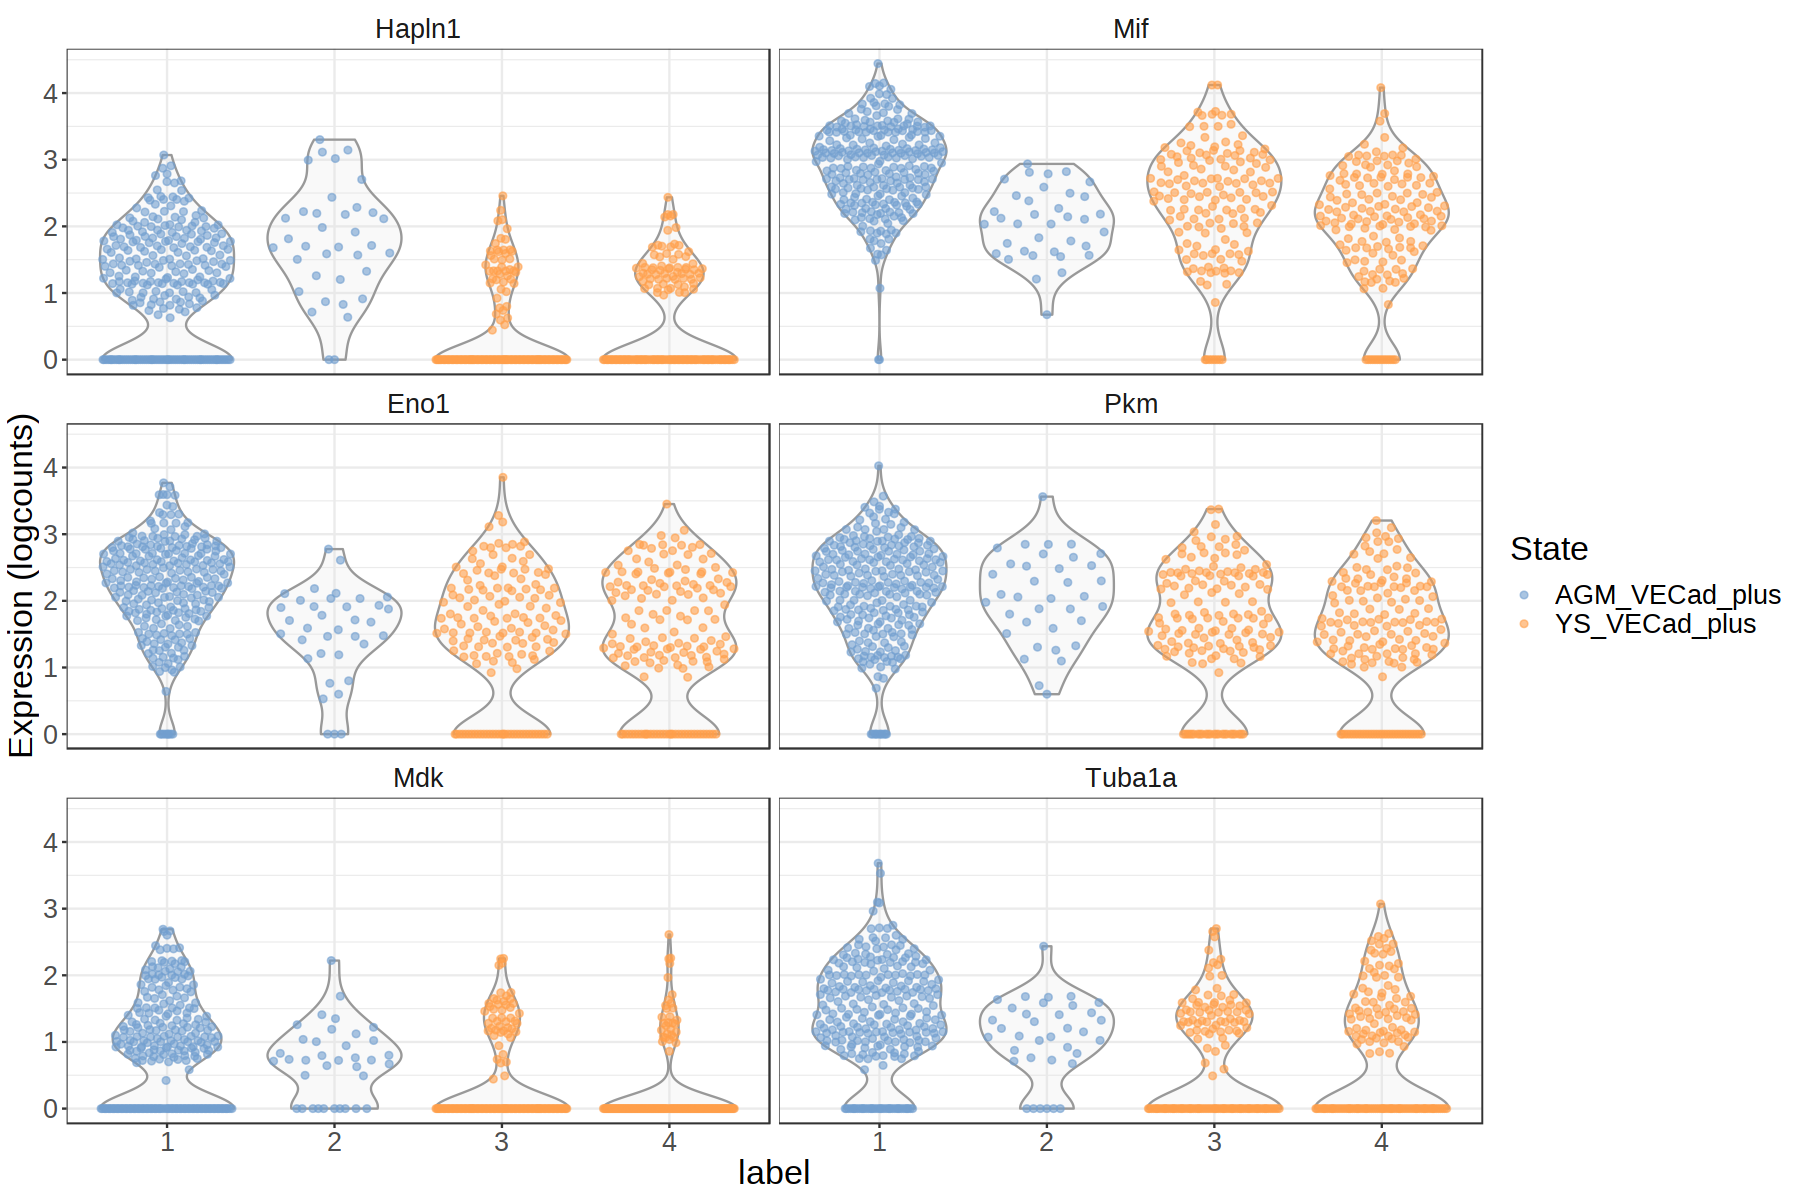

In [112]:
chosen <- marker[["AGM_VECad_plus"]]
ordered <- chosen[order(chosen$mean.AUC, decreasing=TRUE),]
plotExpression(sce_endo, features=head(rownames(ordered)), 
    x="label", colour_by="State") + theme_bw() + theme(text=element_text(size=20), strip.background=element_blank())

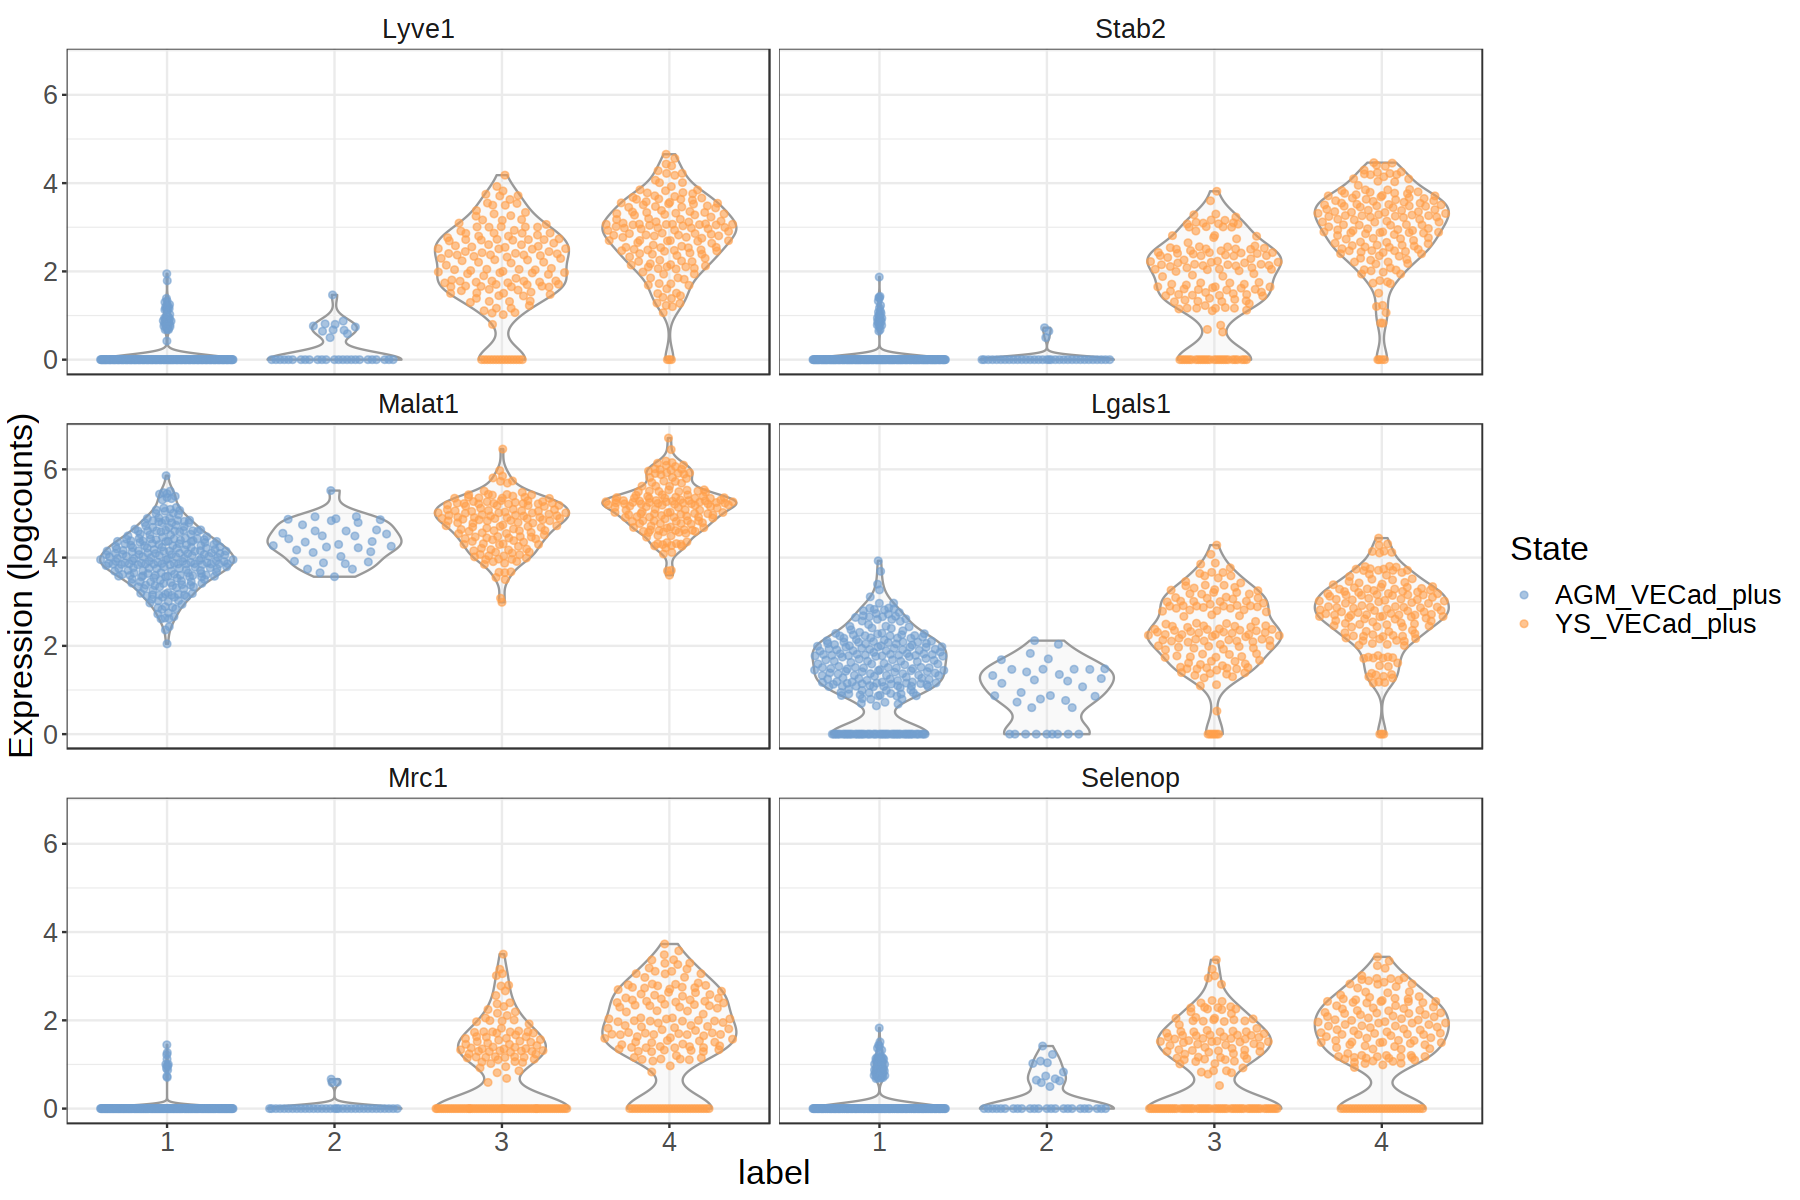

In [113]:
chosen <- marker[["YS_VECad_plus"]]
ordered <- chosen[order(chosen$mean.AUC, decreasing=TRUE),]
plotExpression(sce_endo, features=head(rownames(ordered)), 
    x="label", colour_by="State") + theme_bw() + theme(text=element_text(size=20), strip.background=element_blank())

### E11.5

In [114]:
sce_endo = sce[,meta[State %in% c('YS_VECad_plus', 'AGM_VECad_plus') & stage=='E11.5', rn]]

In [115]:
# Remove Heamoglobin genes as they show up too high, likely as ambient RNA
excl = rownames(sce_endo)[c(grep('^Hbb', rownames(sce_endo)), grep('^Hba', rownames(sce_endo)))]

In [116]:
sce_endo = sce_endo[!rownames(sce_endo) %in% excl,]

In [117]:
# Determine HVGs
decomp = modelGeneVar(sce_endo)
decomp = decomp[decomp$mean > 0.01,]
hvgs = decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

# Subset SingleCellExperiment
sce_filt = sce_endo[hvgs,]

In [118]:
# Dimensionality reduction
sce_filt <- runPCA(sce_filt, ncomponents = 15, ntop=2500)

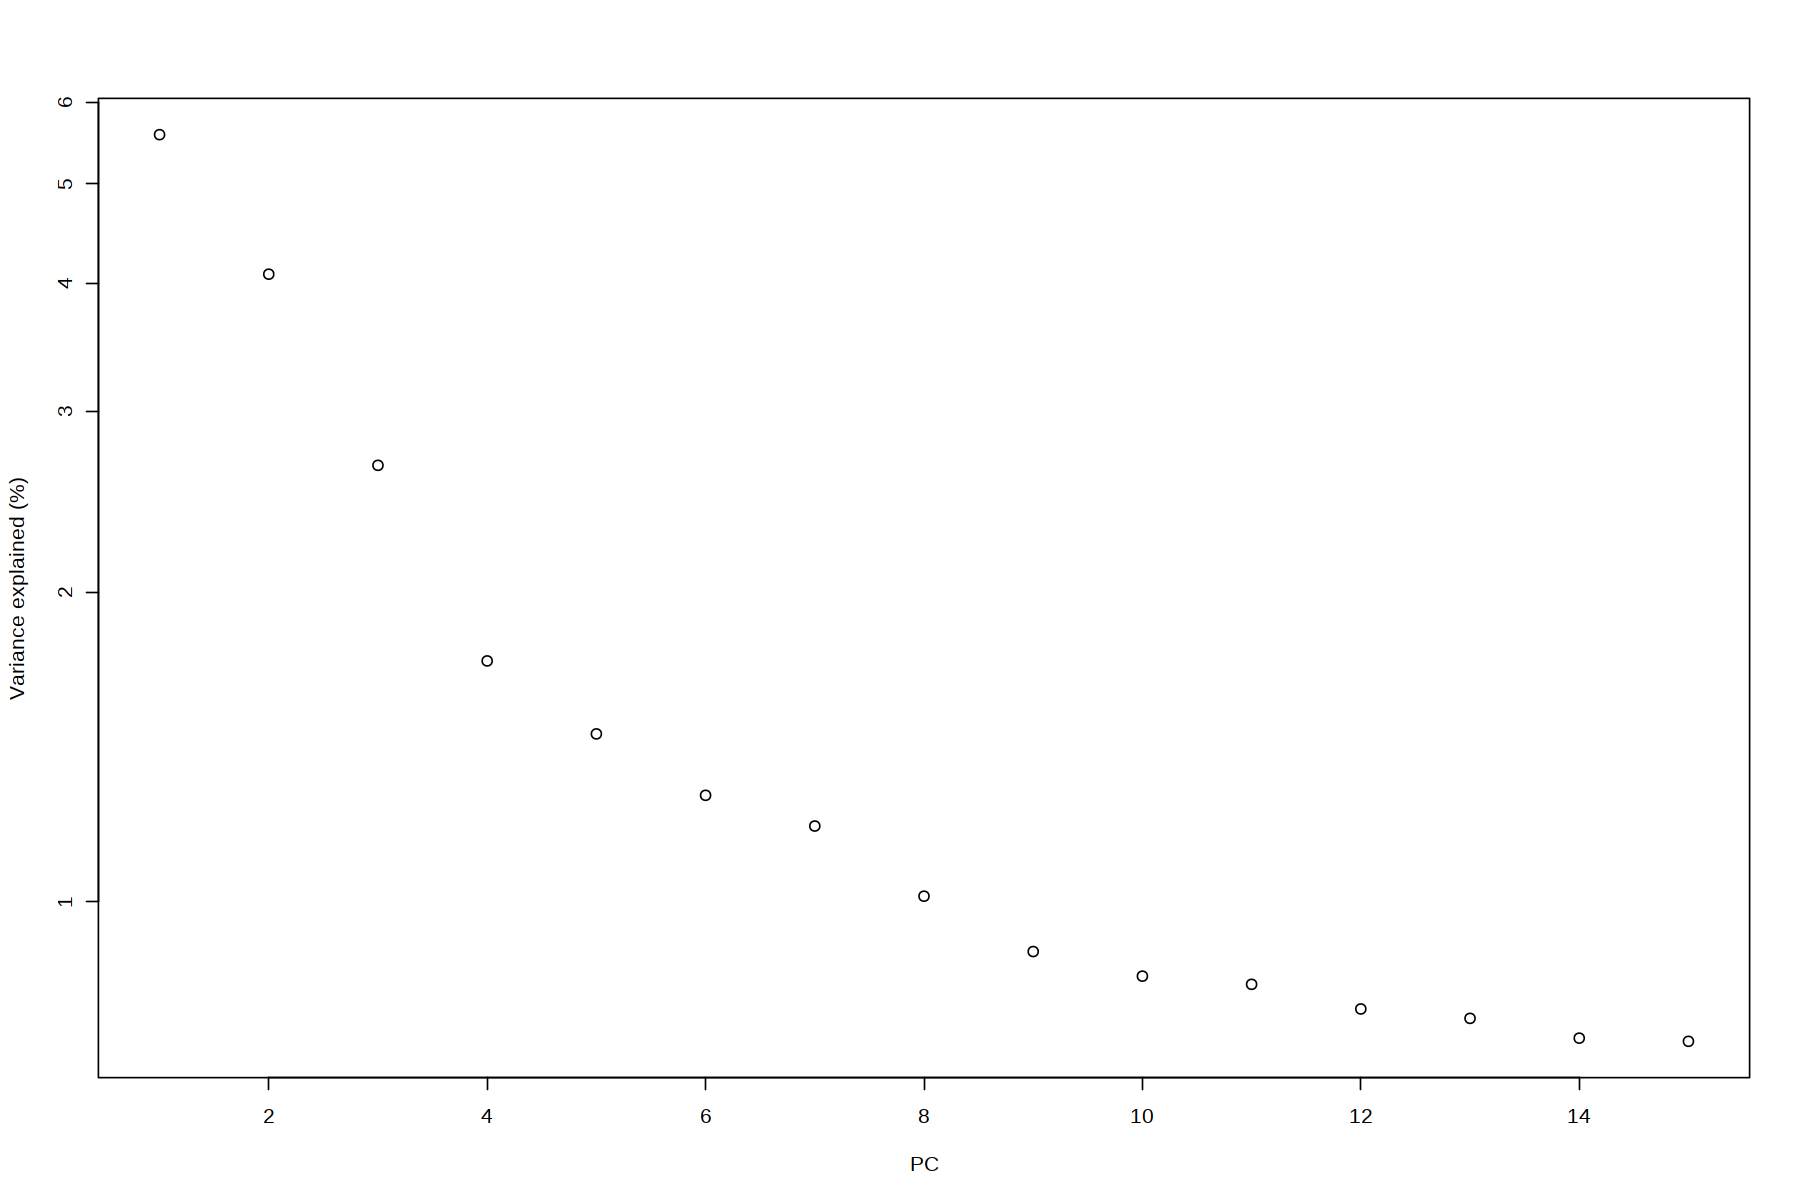

In [119]:
percent.var <- attr(reducedDim(sce_filt), "percentVar")
plot(percent.var, log="y", xlab="PC", ylab="Variance explained (%)")

In [120]:
# Let's use 10 PCs
sce_filt <- runPCA(sce_filt, ncomponents = 10, ntop=2500)

In [121]:
# Cluster
library(bluster)
nn.clusters <- clusterCells(sce_filt, use.dimred="PCA", BLUSPARAM=NNGraphParam(k=20))
colLabels(sce_filt) <- nn.clusters

In [122]:
# UMAP
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 0.2)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

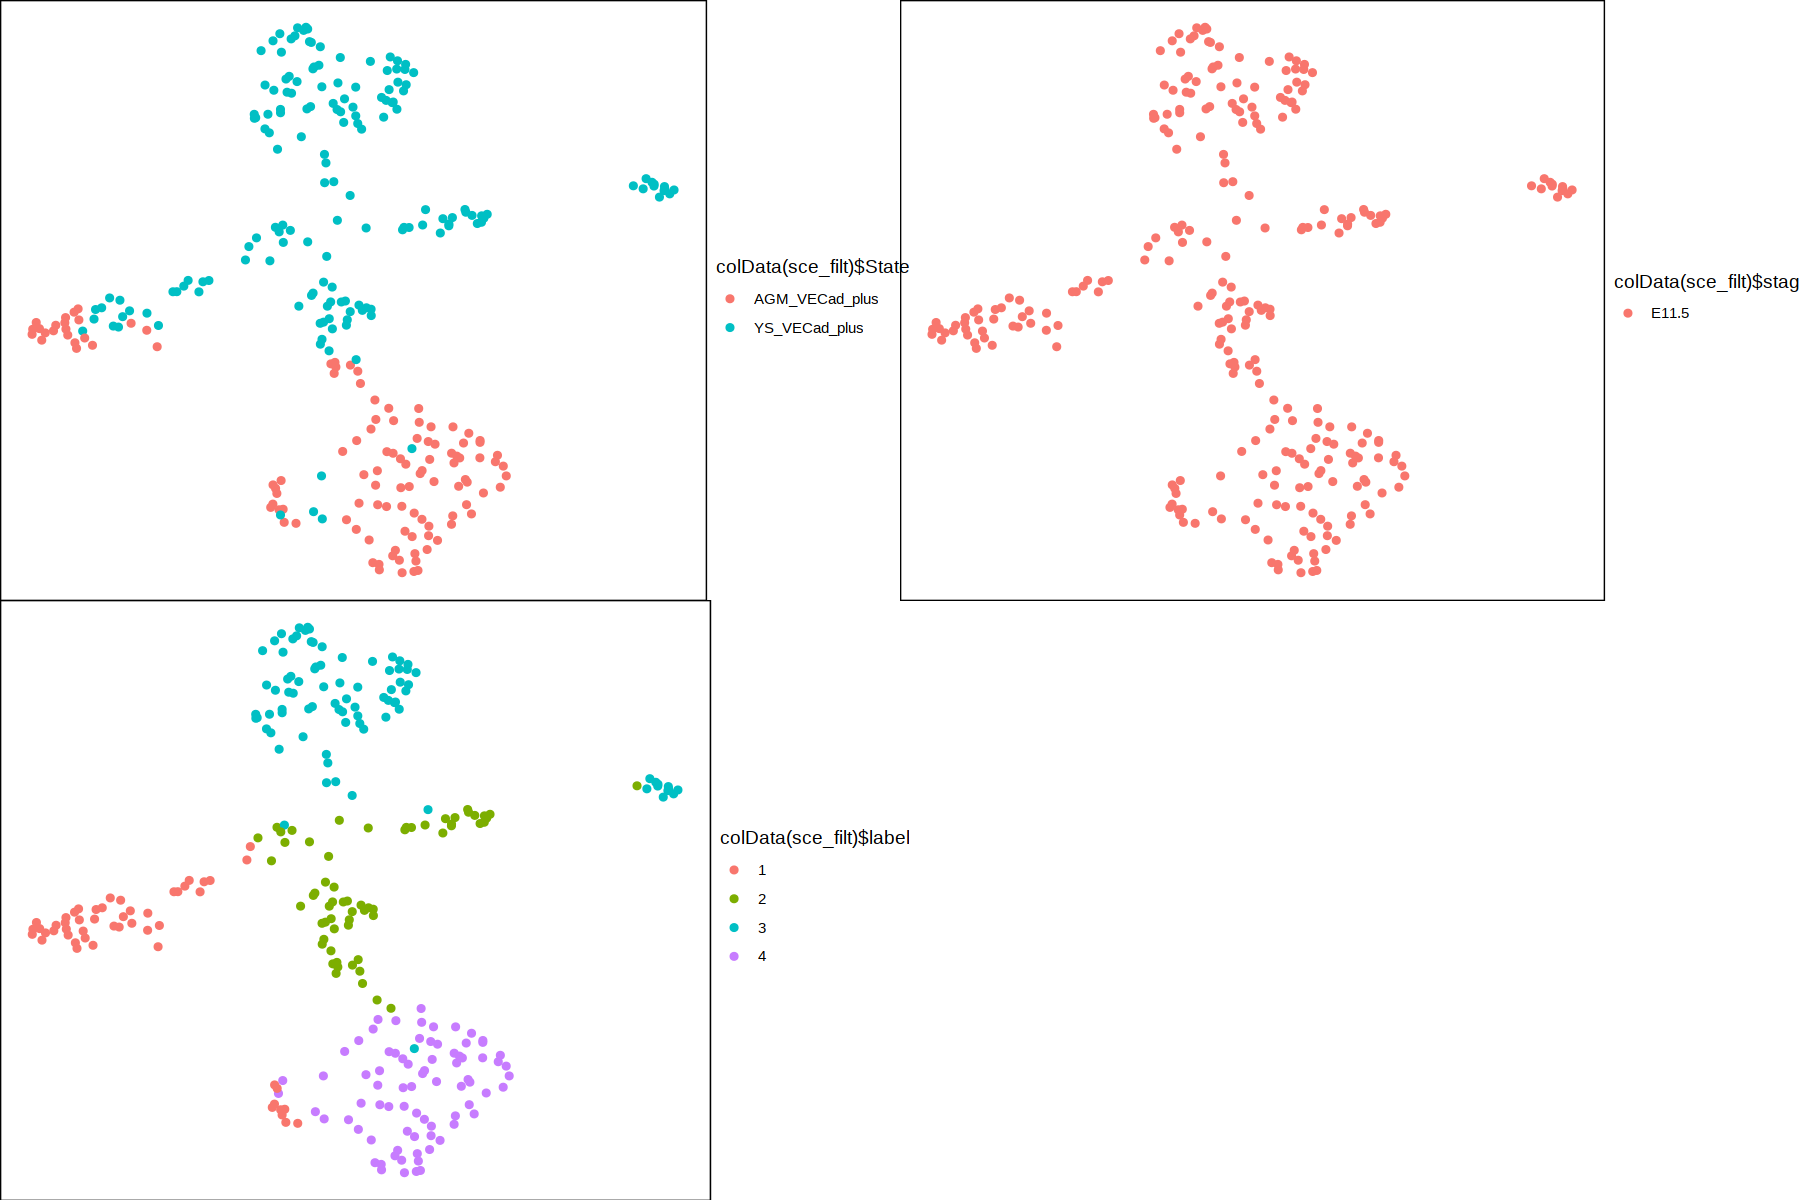

In [123]:
options(repr.plot.width=15,repr.plot.height=10)
ggarrange(
    ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$State)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)),
    ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$stage)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)),
     ggplot(umap.dt, aes(UMAP1, UMAP2, col=colData(sce_filt)$label)) + 
        geom_point() + 
        theme_void() + 
        theme(panel.border=element_rect(color='black', fill=NA)))

In [124]:
marker <- scoreMarkers(sce_endo, colData(sce_endo)$State)
colData(sce_endo)$label = colData(sce_filt)$label

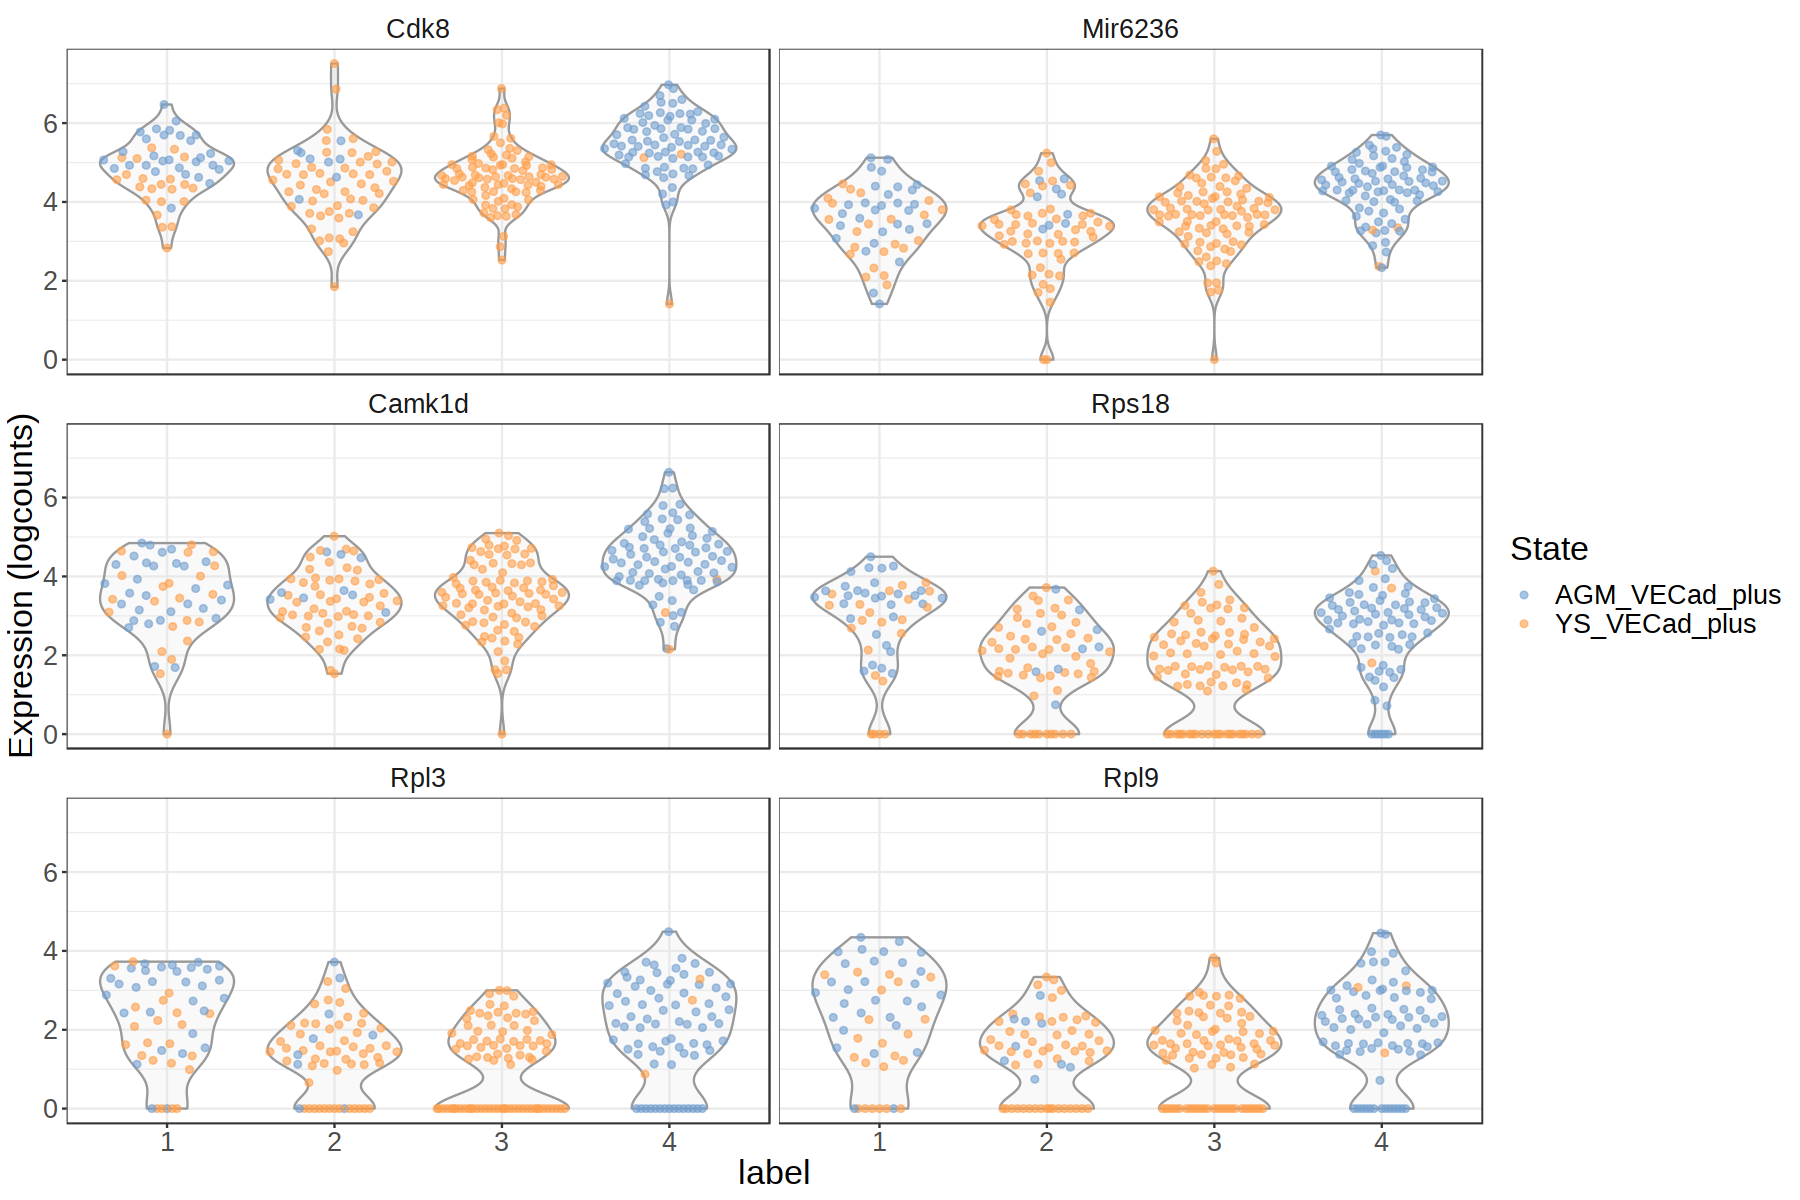

In [125]:
chosen <- marker[["AGM_VECad_plus"]]
ordered <- chosen[order(chosen$mean.AUC, decreasing=TRUE),]
plotExpression(sce_endo, features=head(rownames(ordered)), 
    x="label", colour_by="State") + theme_bw() + theme(text=element_text(size=20), strip.background=element_blank())

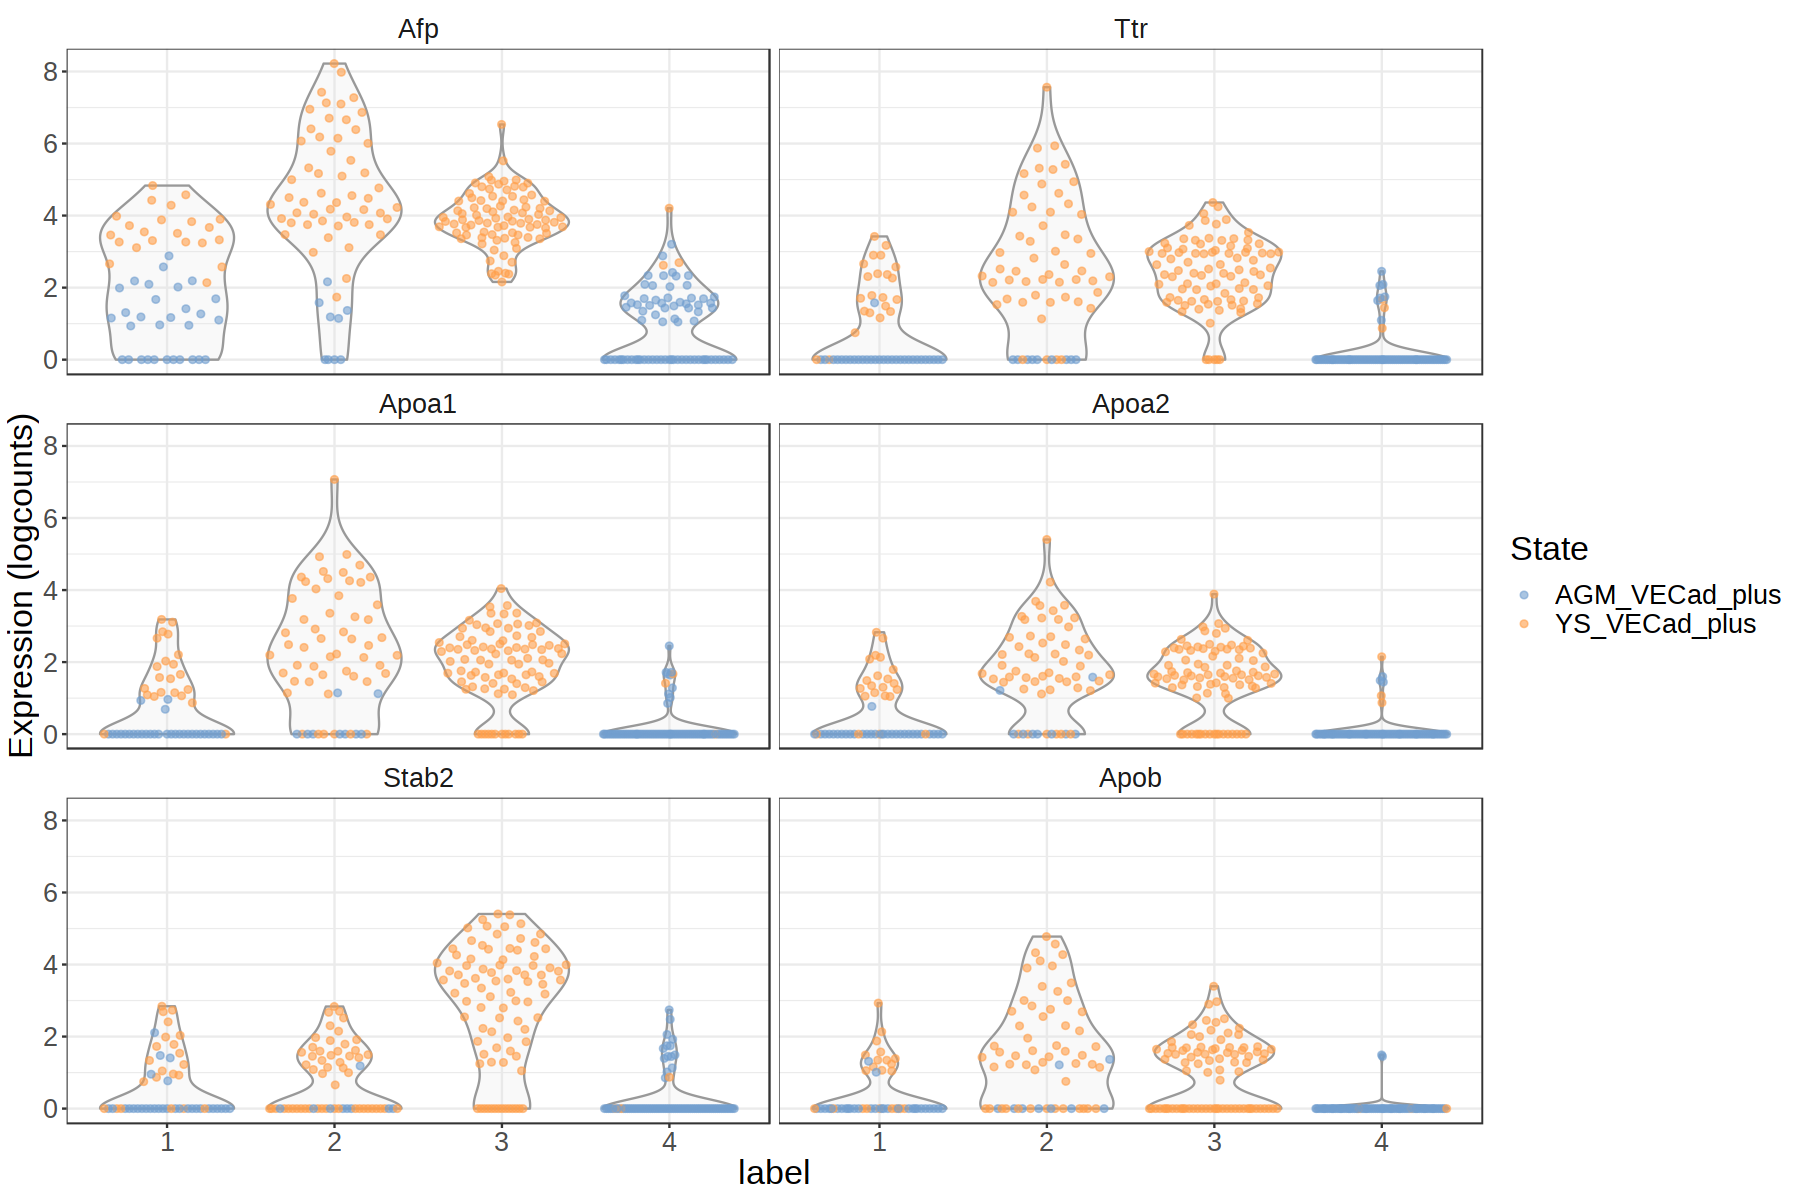

In [126]:
chosen <- marker[["YS_VECad_plus"]]
ordered <- chosen[order(chosen$mean.AUC, decreasing=TRUE),]
plotExpression(sce_endo, features=head(rownames(ordered)), 
    x="label", colour_by="State") + theme_bw() + theme(text=element_text(size=20), strip.background=element_blank())